# NyayaGrant AI - Exploratory Data Analysis & ML Pipeline Walkthrough

Welcome to the official **NyayaGrant AI** Machine Learning notebook.  
This notebook demonstrates:
1. **Synthetic Data Generation & Data Cleaning**
2. **Distribution & Correlation Analysis** of Financial, Academic, Opportunity, Vulnerability, and Special Circumstance features
3. **5-Pillar Score Distributions** (Financial Need, Academic Potential, Opportunity Gap, Social Vulnerability, Special Circumstances)
4. **Model Performance Evaluation** (RandomForest vs. XGBoost / GradientBoosting)
5. **Explainable AI (SHAP Values & Instance Attribution)**
6. **Demographic Fairness Audit**
7. **Budget Allocation & Optimization Strategy Engine**

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure parent directory & src are on sys.path for robust imports
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../src'))

# Set style
sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Dataset

In [2]:
# Load pre-generated dataset
data_path = "../data/scholarship_applicants.csv"
if not os.path.exists(data_path):
    from src.data_preprocessing import prepare_and_save_data
    df, _, _, _, _ = prepare_and_save_data("..")
else:
    df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 1200 rows, 53 columns


,student_id,age,gender,state,district,urban_rural,education_level,course_type,annual_family_income,family_members,...,expense_income_ratio,debt_burden_score,opportunity_gap_score,financial_need_score,academic_potential_score,vulnerability_score,special_circumstances_score,academic_improvement,final_score,scholarship_eligible
0,STU0001,22,Male,Bihar,District_BIH_1,Rural,Undergraduate,Vocational,116000.0,4,...,1.356034,0.000000,39.96,79.95,64.52,0.0,0.00,1.71,52.10,1
1,STU0002,19,Male,Odisha,District_ODI_1,Urban,Undergraduate,STEM,94000.0,6,...,1.155319,0.000000,33.61,71.02,53.12,0.0,0.00,-2.58,44.86,0
2,STU0003,23,Female,Uttar Pradesh,District_UTT_4,Rural,Undergraduate,STEM,141000.0,3,...,1.314184,1.007092,44.17,85.59,62.07,0.0,25.53,6.41,55.58,1
3,STU0004,20,Female,Odisha,District_ODI_3,Urban,Higher Secondary,Arts,153000.0,3,...,0.979739,0.000000,10.69,67.18,60.60,15.0,0.00,8.54,43.05,0
4,STU0005,22,Female,West Bengal,District_WES_1,Urban,Postgraduate,Commerce,89000.0,4,...,1.388764,0.044944,62.84,63.23,59.79,15.0,0.00,3.61,51.90,1


## 2. Score Distributions (5 Pillars & Final Priority Score)

In [3]:
score_cols = [
    'financial_need_score', 'academic_potential_score', 
    'opportunity_gap_score', 'vulnerability_score', 
    'special_circumstances_score', 'final_score'
]

df[score_cols].describe()

,financial_need_score,academic_potential_score,opportunity_gap_score,vulnerability_score,special_circumstances_score,final_score
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,71.456050,60.020092,39.114683,14.512500,13.464400,50.687692
std,15.118747,11.262532,17.282732,15.300433,19.764927,8.543600
min,9.070000,30.060000,2.550000,0.000000,0.000000,19.800000
25%,63.032500,51.762500,26.185000,0.000000,0.000000,45.020000
50%,73.300000,60.260000,39.390000,15.000000,0.000000,51.240000
75%,81.382500,68.570000,50.742500,25.000000,25.000000,56.590000
max,99.990000,88.850000,90.620000,90.000000,100.000000,73.170000


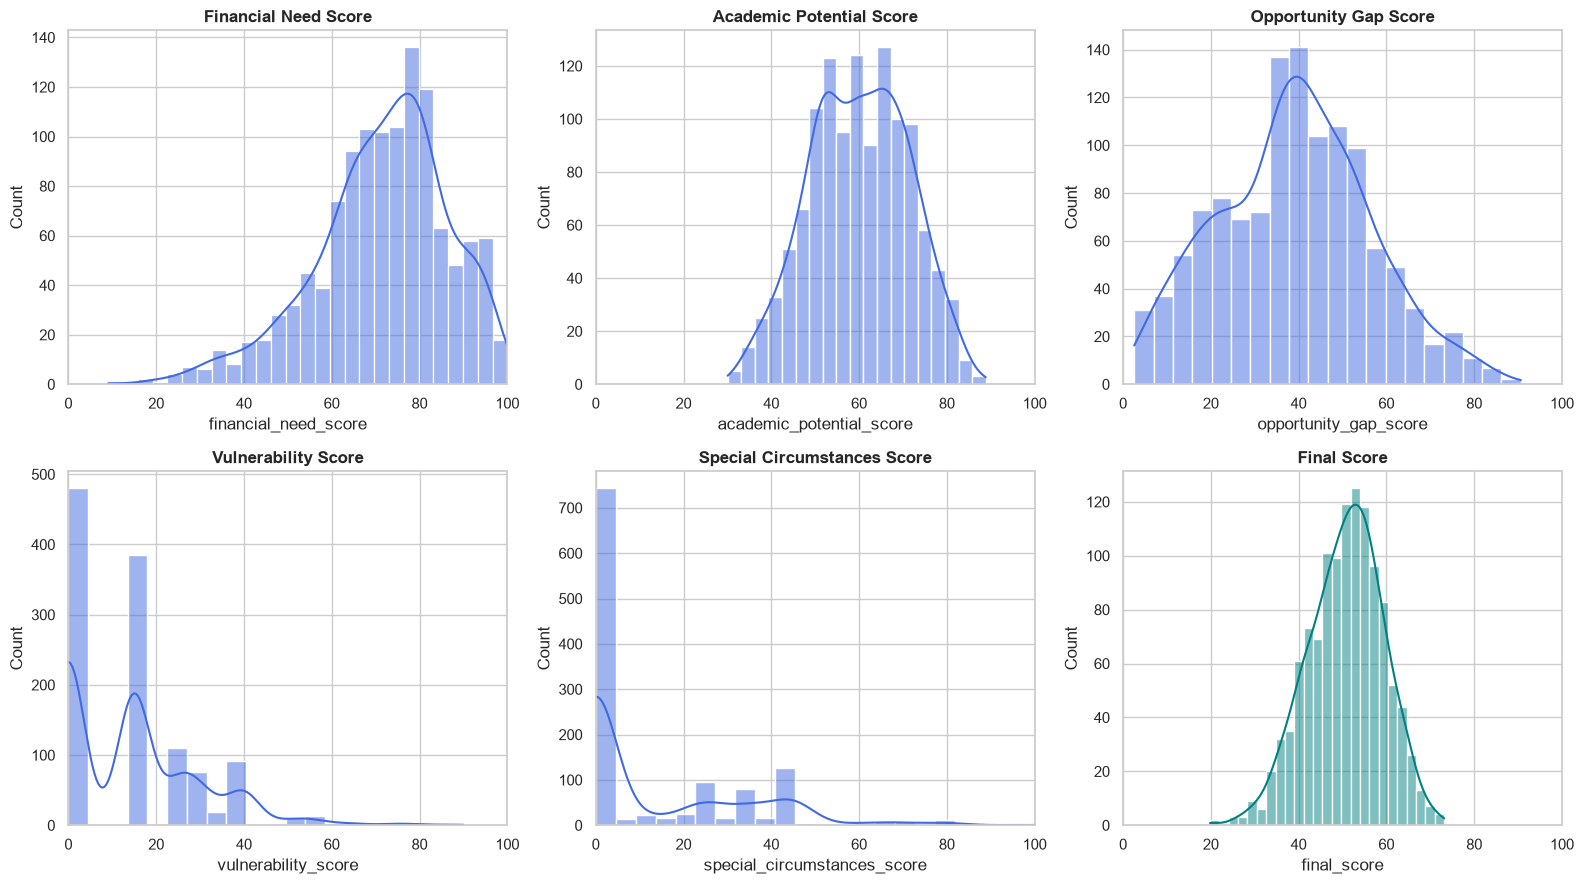

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(score_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal' if col=='final_score' else 'royalblue')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlim(0, 100)

plt.tight_layout()
plt.show()

## 3. Academic Potential vs. Opportunity Gap Analysis
Notice how students facing high resource constraints (Opportunity Gap) who maintain academic improvement achieve recognized academic potential.

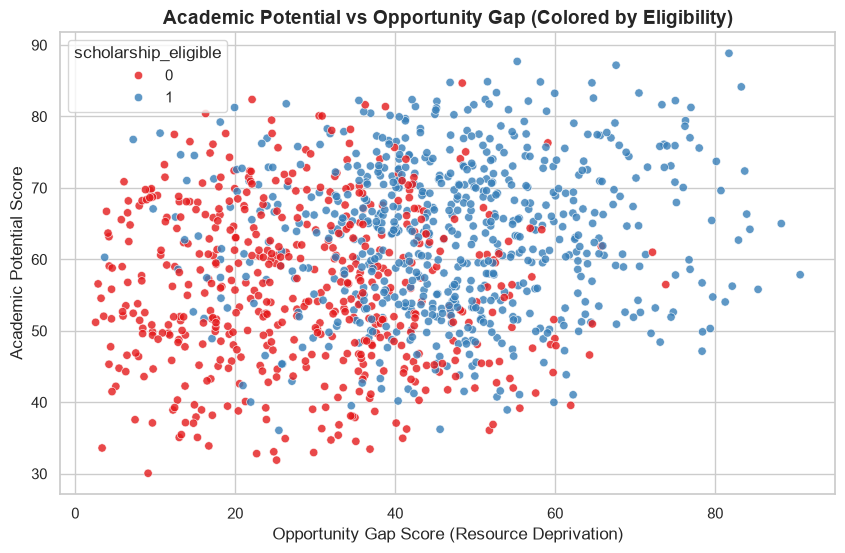

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='opportunity_gap_score', 
    y='academic_potential_score', 
    hue='scholarship_eligible', 
    palette='Set1', 
    alpha=0.8
)
plt.title('Academic Potential vs Opportunity Gap (Colored by Eligibility)', fontsize=14, fontweight='bold')
plt.xlabel('Opportunity Gap Score (Resource Deprivation)')
plt.ylabel('Academic Potential Score')
plt.show()

## 4. Run Model Evaluation & Fairness Audit

In [6]:
from src.evaluate_model import evaluate_scholarship_model
from src.fairness_audit import audit_fairness, print_fairness_report

metrics = evaluate_scholarship_model(base_dir="..")
fairness_audit = audit_fairness(df)
print_fairness_report(fairness_audit)


NYAYAGRANT AI - MODEL EVALUATION REPORT

Model Type: XGBClassifier
Test Dataset Size: 240 samples

PRIMARY PERFORMANCE METRICS:
--------------------------------------------------
Accuracy : 0.9167
Precision: 0.9191
Recall   : 0.9328  [PRIORITY FOR FAIR ALLOCATION]
F1 Score : 0.9259  [PRIORITY FOR HARMONIC BALANCE]
ROC-AUC  : 0.9782

CONFUSION MATRIX:
--------------------------------------------------
[ [ TN:  95 , FP:  11 ]
  [ FN:   9 , TP: 125 ] ]

CLASSIFICATION REPORT:
--------------------------------------------------
                  precision    recall  f1-score   support

Not Eligible (0)       0.91      0.90      0.90       106
    Eligible (1)       0.92      0.93      0.93       134

        accuracy                           0.92       240
       macro avg       0.92      0.91      0.92       240
    weighted avg       0.92      0.92      0.92       240


TOP 10 MOST IMPORTANT FEATURES:
--------------------------------------------------
  1. financial_need_score          

## 5. Budget Allocation Engine Simulation

In [7]:
from src.budget_optimizer import allocate_budget

budget = 1000000.0  # INR 10,00,000
allocation_res = allocate_budget(df, total_budget=budget, mode='greedy')

print(f"Total Applicants: {allocation_res['total_applicants']}")
print(f"Beneficiaries Funded: {allocation_res['number_of_beneficiaries']}")
print(f"Total Allocated: INR {allocation_res['amount_allocated']:,.2f}")
print(f"Remaining Budget: INR {allocation_res['remaining_budget']:,.2f}")

Total Applicants: 1200
Beneficiaries Funded: 29
Total Allocated: INR 995,000.00
Remaining Budget: INR 5,000.00
